In [1]:
#ДЗ 
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

In [18]:
image = cv2.imread('sar_3.jpg')
image_line = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

<h1>1. Выделение наиболее протяженного участка при помощи преобразования Хафа</h1>

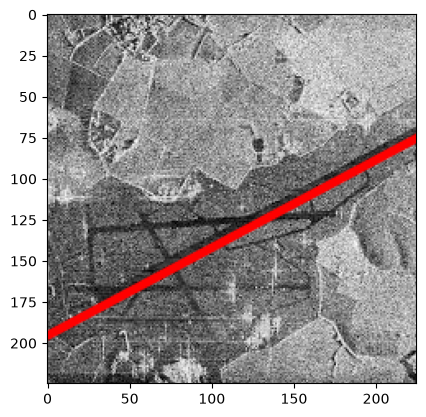

In [19]:
edges = cv2.Canny(image_gray,130,400, apertureSize = 3)
lines = cv2.HoughLines(edges, 1, np.pi / 180, 120)

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(image_line, pt1, pt2, (255, 0, 0), 3, cv2.LINE_AA)

plt.imshow(image_line)

<h1>2. Алгоритмы бинаризации</h1>

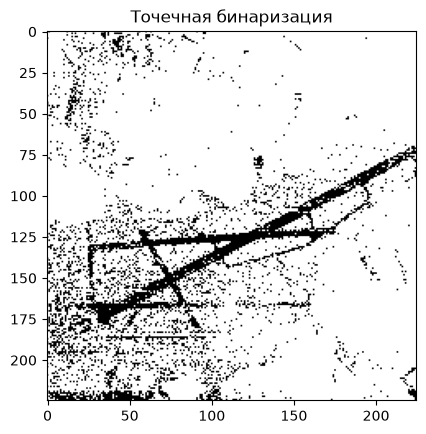

In [20]:
bin_img = copy.deepcopy(image_gray)
T  = 70
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255
plt.title('Точечная бинаризация')
plt.imshow(bin_img, cmap="gray")

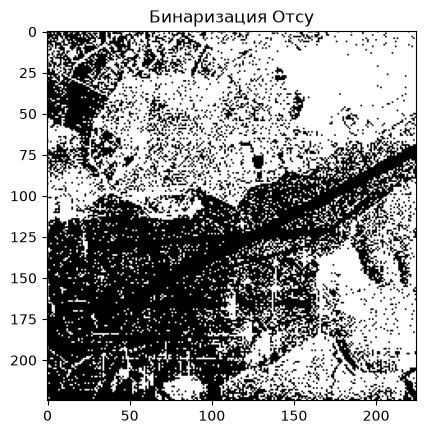

In [21]:
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.title('Бинаризация Отсу')
plt.imshow(th2, cmap="gray")

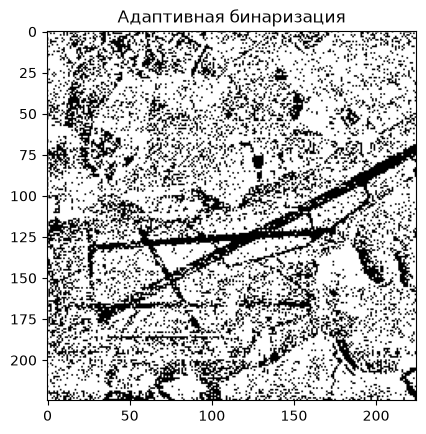

In [22]:
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)
plt.title('Адаптивная бинаризация')
plt.imshow(th3, cmap="gray")

<h1>Выделение участка дорожной полосы</h1>

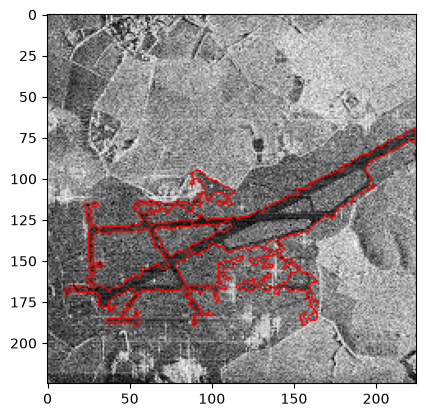

In [24]:
blurred = cv2.GaussianBlur(th3, (7, 7), 0)
thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
lane_image = image.copy()
if contours:
    for contour in contours:
        area = cv2.contourArea(contour)
        if area > 500:
            cv2.drawContours(lane_image, [contour], -1, (0, 0, 255), 1    )  
lane_image = cv2.cvtColor(lane_image, cv2.COLOR_BGR2RGB)
plt.imshow(lane_image)
plt.show()